In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, 
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from joblib import dump
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Exploratory Data Analysis

In [5]:
data = pd.read_csv('/Users/sarimkazmi/Desktop/diabetes_prediction_dataset.csv')

In [6]:
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


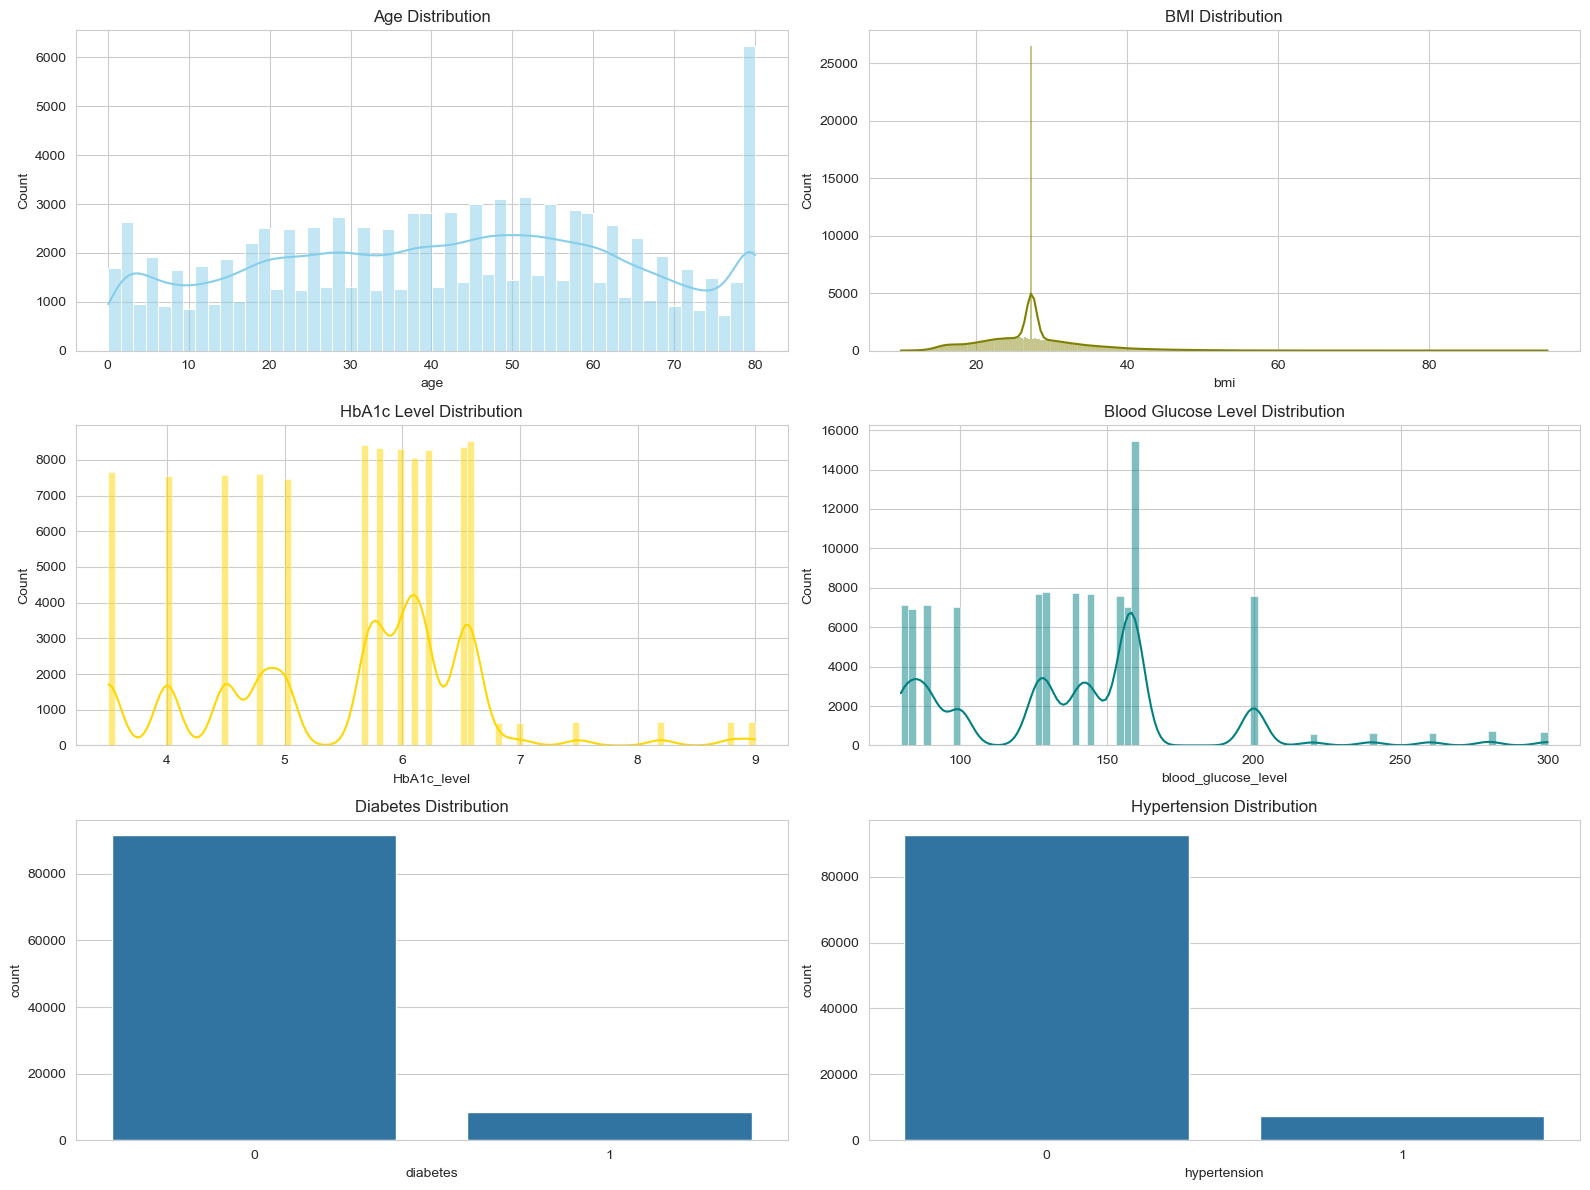

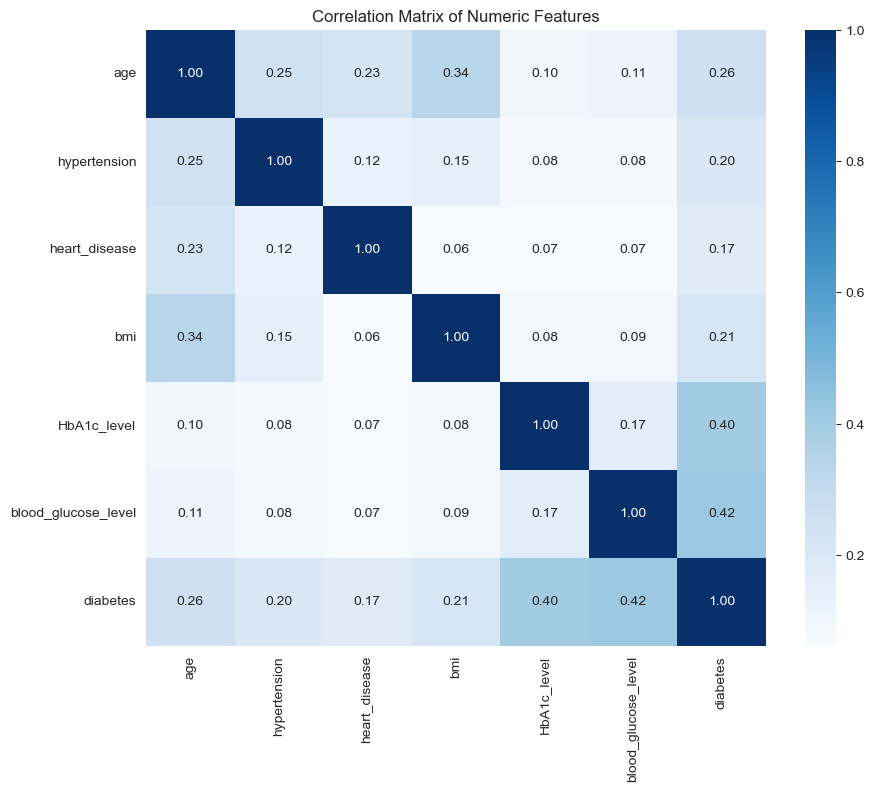

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

df = data
missing_values = df.isnull().sum()
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()

fig, axs = plt.subplots(3, 2, figsize=(16, 12))
sns.histplot(data=df, x="age", kde=True, ax=axs[0, 0], color='skyblue').set(title='Age Distribution')
sns.histplot(data=df, x="bmi", kde=True, ax=axs[0, 1], color='olive').set(title='BMI Distribution')
sns.histplot(data=df, x="HbA1c_level", kde=True, ax=axs[1, 0], color='gold').set(title='HbA1c Level Distribution')
sns.histplot(data=df, x="blood_glucose_level", kde=True, ax=axs[1, 1], color='teal').set(title='Blood Glucose Level Distribution')
sns.countplot(data=df, x="diabetes", ax=axs[2, 0]).set(title='Diabetes Distribution')
sns.countplot(data=df, x="hypertension", ax=axs[2, 1]).set(title='Hypertension Distribution')

plt.tight_layout()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='Blues')
plt.title('Correlation Matrix of Numeric Features')

plt.show()
missing_values

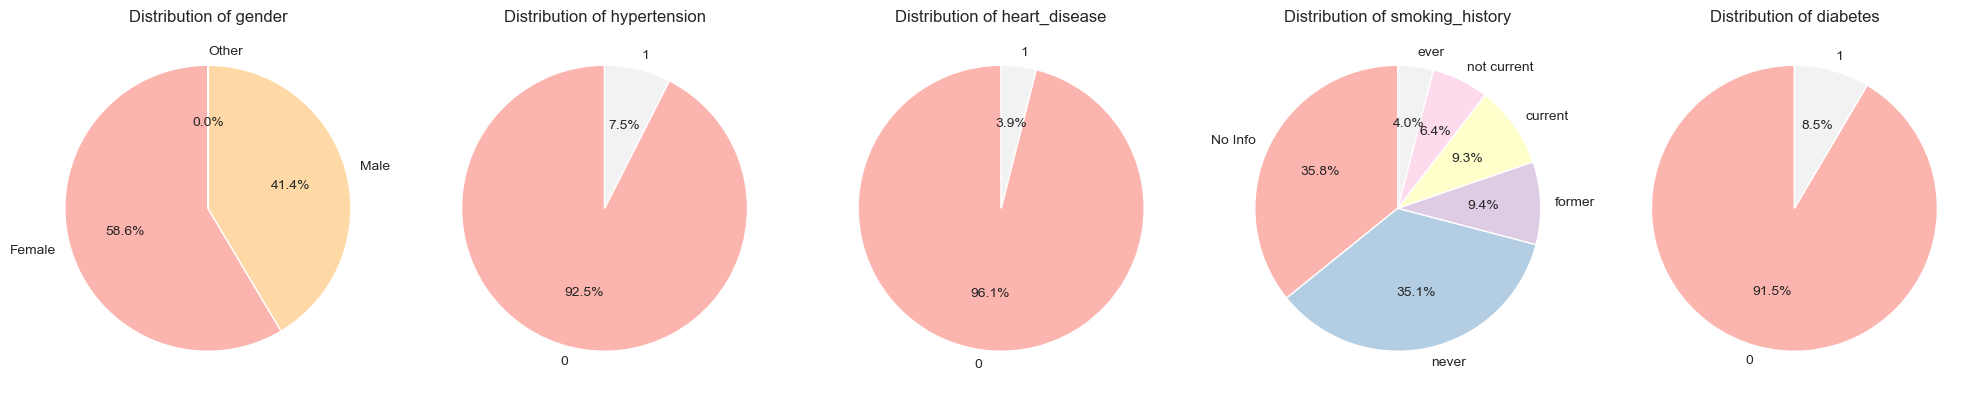

In [8]:
import matplotlib.pyplot as plt

# Function to plot pie charts for given columns
def plot_pie_charts(data, columns):
    fig, axes = plt.subplots(1, len(columns), figsize=(20, 5))
    for ax, column in zip(axes, columns):
        data[column].value_counts().plot.pie(autopct='%1.1f%%', ax=ax, startangle=90, cmap='Pastel1')
        ax.set_ylabel('')
        ax.set_title(f'Distribution of {column}')
    plt.tight_layout()
    plt.show()

# Columns to create pie charts for
columns = ['gender', 'hypertension', 'heart_disease', 'smoking_history', 'diabetes']
plot_pie_charts(data, columns)

In [ ]:

print("Original shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

df = df.drop_duplicates()
print("\nAfter removing duplicates:", df.shape)


num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after handling:\n", df.isnull().sum())
print("\nClass distribution:")
print(df['diabetes'].value_counts(normalize=True).round(3))

Original shape: (100000, 9)

Missing values:
 gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicates: 3854

After removing duplicates: (96146, 9)

Missing values after handling:
 gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Class distribution:
diabetes
0    0.912
1    0.088
Name: proportion, dtype: float64


In [ ]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

categorical_features = ['gender', 'smoking_history']
numerical_features = [c for c in X.columns if c not in categorical_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 76916 | Test size: 19230


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

In [12]:
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=150, max_depth=10,
        min_samples_split=5, min_samples_leaf=4,
        random_state=42, n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='logloss', n_jobs=-1
    )
}

In [41]:
def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auprc = average_precision_score(y_test, y_proba)
    
    print(f"{name}")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"AUPRC    : {auprc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    
    return {
        'model_name': name,
        'accuracy': acc,
        'auprc': auprc,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'pipeline': pipeline
    }

In [47]:

baseline_results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    
    baseline_results[name] = evaluate_model(f"Baseline → {name}", pipe, X_test, y_test)
    
    if name == "RandomForest":
        dump(pipe, "model.joblib")
        

Baseline → RandomForest
Accuracy : 97.16%
AUPRC    : 0.8710

Classification Report:
              precision    recall  f1-score   support

           0     0.9698    1.0000    0.9847     17534
           1     1.0000    0.6781    0.8082      1696

    accuracy                         0.9716     19230
   macro avg     0.9849    0.8390    0.8964     19230
weighted avg     0.9725    0.9716    0.9691     19230

Baseline → LogisticRegression
Accuracy : 95.96%
AUPRC    : 0.8173

Classification Report:
              precision    recall  f1-score   support

           0     0.9660    0.9906    0.9782     17534
           1     0.8686    0.6392    0.7364      1696

    accuracy                         0.9596     19230
   macro avg     0.9173    0.8149    0.8573     19230
weighted avg     0.9574    0.9596    0.9568     19230

Baseline → XGBoost
Accuracy : 97.12%
AUPRC    : 0.8810

Classification Report:
              precision    recall  f1-score   support

           0     0.9710    0.9983    0

In [45]:

# Calculate scale_pos_weight for XGBoost
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

weighted_models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=150, max_depth=10,
        min_samples_split=5, min_samples_leaf=4,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42, eval_metric='logloss', n_jobs=-1
    )
}

weighted_results = {}

for name, model in weighted_models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    weighted_results[name] = evaluate_model(f"ClassWeight → {name}", pipe, X_test, y_test)
    

ClassWeight → RandomForest
Accuracy : 89.80%
AUPRC    : 0.8738

Classification Report:
              precision    recall  f1-score   support

           0     0.9897    0.8975    0.9413     17534
           1     0.4601    0.9033    0.6096      1696

    accuracy                         0.8980     19230
   macro avg     0.7249    0.9004    0.7755     19230
weighted avg     0.9430    0.8980    0.9121     19230

ClassWeight → LogisticRegression
Accuracy : 88.46%
AUPRC    : 0.8166

Classification Report:
              precision    recall  f1-score   support

           0     0.9870    0.8850    0.9332     17534
           1     0.4253    0.8797    0.5734      1696

    accuracy                         0.8846     19230
   macro avg     0.7062    0.8824    0.7533     19230
weighted avg     0.9375    0.8846    0.9015     19230

ClassWeight → XGBoost
Accuracy : 90.63%
AUPRC    : 0.8798

Classification Report:
              precision    recall  f1-score   support

           0     0.9901    0.

In [46]:
smote_results = {}

for name, model in models.items():
    pipe = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    smote_results[name] = evaluate_model(f"SMOTE → {name}", pipe, X_test, y_test)
   

SMOTE → RandomForest
Accuracy : 90.85%
AUPRC    : 0.8688

Classification Report:
              precision    recall  f1-score   support

           0     0.9861    0.9126    0.9479     17534
           1     0.4895    0.8667    0.6257      1696

    accuracy                         0.9085     19230
   macro avg     0.7378    0.8897    0.7868     19230
weighted avg     0.9423    0.9085    0.9195     19230

SMOTE → LogisticRegression
Accuracy : 88.46%
AUPRC    : 0.8167

Classification Report:
              precision    recall  f1-score   support

           0     0.9870    0.8851    0.9332     17534
           1     0.4253    0.8791    0.5732      1696

    accuracy                         0.8846     19230
   macro avg     0.7061    0.8821    0.7532     19230
weighted avg     0.9374    0.8846    0.9015     19230

SMOTE → XGBoost
Accuracy : 97.04%
AUPRC    : 0.8766

Classification Report:
              precision    recall  f1-score   support

           0     0.9734    0.9947    0.9839    

In [27]:
all_results = []

for technique, res_dict in [
    ("Baseline", baseline_results),
    ("ClassWeight", weighted_results),
    ("SMOTE", smote_results)
]:
    for model_name, metrics in res_dict.items():
        all_results.append({
            'Technique': technique,
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'AUPRC': metrics['auprc']
        })

results_df = pd.DataFrame(all_results)
print(results_df.to_string(index=False))

  Technique              Model  Accuracy    AUPRC
   Baseline       RandomForest  0.971607 0.870989
   Baseline LogisticRegression  0.959646 0.817293
   Baseline            XGBoost  0.971243 0.880990
ClassWeight       RandomForest  0.897972 0.873797
ClassWeight LogisticRegression  0.884555 0.816641
ClassWeight            XGBoost  0.906344 0.879794
      SMOTE       RandomForest  0.908528 0.868846
      SMOTE LogisticRegression  0.884555 0.816738
      SMOTE            XGBoost  0.970359 0.876588


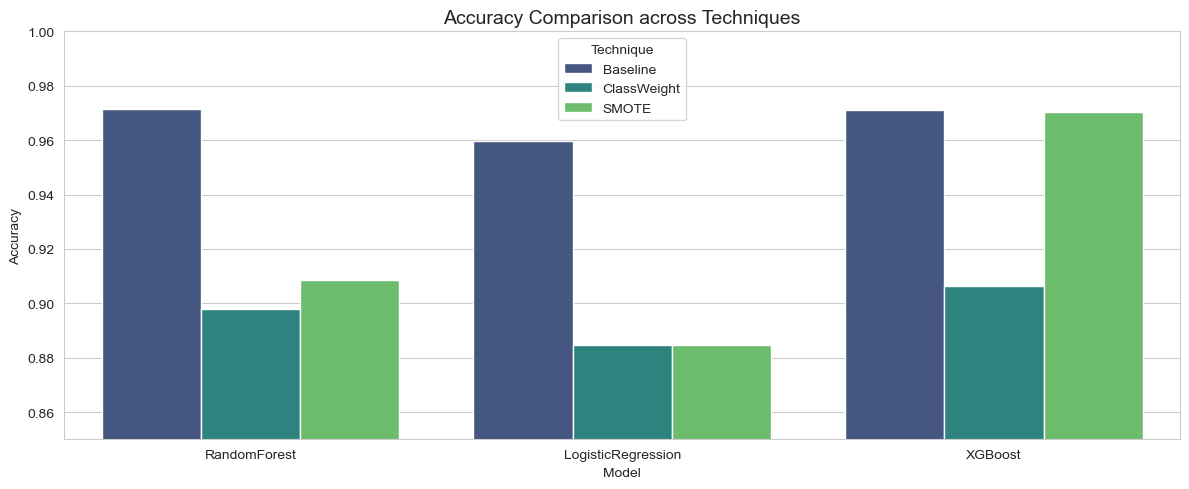

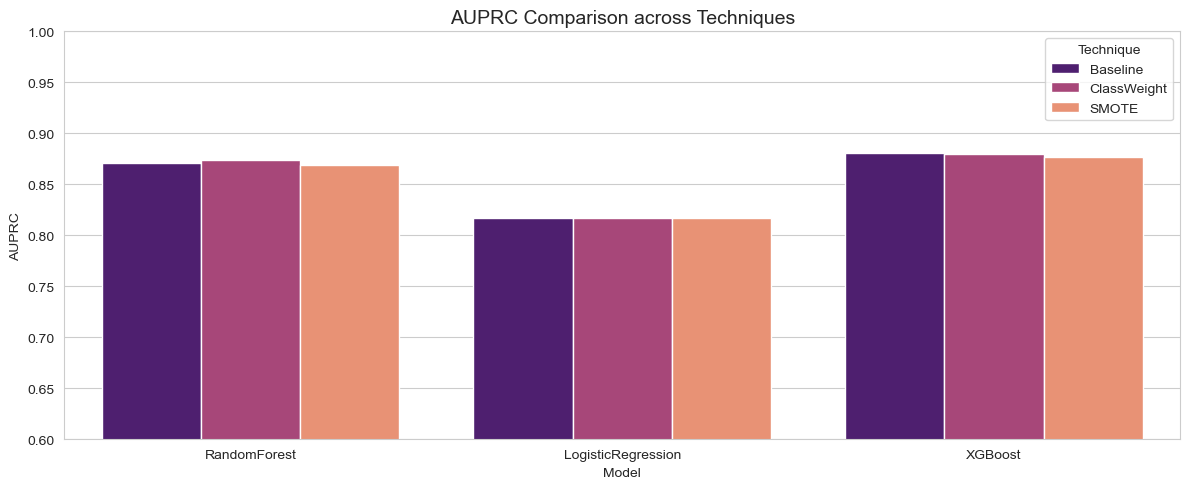

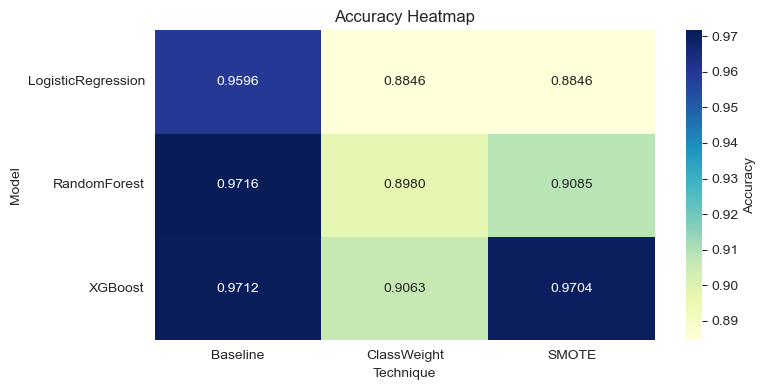

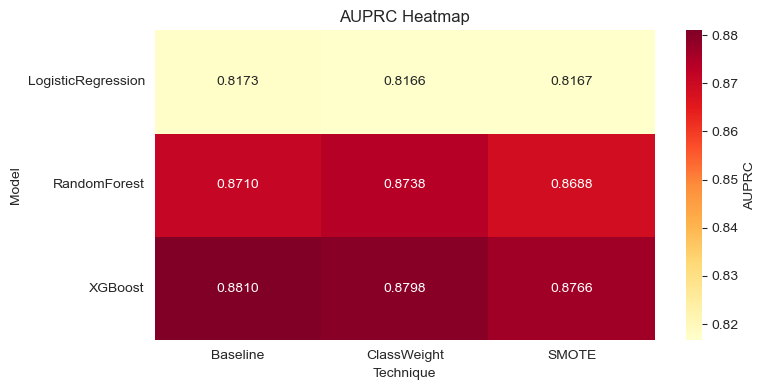

In [28]:
# ---- Accuracy comparison ----
plt.figure(figsize=(12, 5))
sns.barplot(data=results_df, x='Model', y='Accuracy', hue='Technique', palette='viridis')
plt.title('Accuracy Comparison across Techniques', fontsize=14)
plt.ylim(0.85, 1.0)
plt.legend(title='Technique')
plt.tight_layout()
plt.show()

# ---- AUPRC comparison ----
plt.figure(figsize=(12, 5))
sns.barplot(data=results_df, x='Model', y='AUPRC', hue='Technique', palette='magma')
plt.title('AUPRC Comparison across Techniques', fontsize=14)
plt.ylim(0.6, 1.0)
plt.legend(title='Technique')
plt.tight_layout()
plt.show()

# ---- Heatmap of Accuracy ----
pivot_acc = results_df.pivot(index='Model', columns='Technique', values='Accuracy')
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_acc, annot=True, fmt='.4f', cmap='YlGnBu', cbar_kws={'label': 'Accuracy'})
plt.title('Accuracy Heatmap')
plt.tight_layout()
plt.show()

# ---- Heatmap of AUPRC ----
pivot_auprc = results_df.pivot(index='Model', columns='Technique', values='AUPRC')
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_auprc, annot=True, fmt='.4f', cmap='YlOrRd', cbar_kws={'label': 'AUPRC'})
plt.title('AUPRC Heatmap')
plt.tight_layout()
plt.show()